In [1]:
import numpy as np
import pandas as pd
import pickle 
import importlib
import run_ql_pb_opt
importlib.reload(run_ql_pb_opt)
from run_ql_pb_opt import ql_pb_opt
from tqdm import tqdm
from joblib import Parallel, delayed

geo_list = ['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA', 'HI', 
'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 
'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 
'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY', 'US']

geo_big = ['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI', 'NJ', 'VA', 'WA']
geo_med = ['AZ', 'TN', 'MA', 'IN', 'MO', 'MD', 'CO', 'WI', 'MN', 'SC', 'AL', 'LA', 'KY', 'OR', 'OK', 'CT']
geo_small =  ['UT', 'NV', 'IA', 'AR', 'KS', 'NE', 'MS', 'NM', 'ID', 'NE', 'WV', 'HI', 'NH', 'ME', 'MT', 'RI', 'DE', 'SD', 'ND', 'AK', 'DC', 'VT', 'WY']

alpha_list = np.array([0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99])

print(set(geo_big + geo_med + geo_small) - set(geo_list))
print(set(geo_list) - set(geo_big + geo_med + geo_small))

set()
{'US'}


In [5]:
import os

def decimal_to_str(eta):
    return str(np.round(eta, 4)).replace('.', ',')
    
def exp_name_string_state_ql_pb(w, geo, eta, round_Y_F, suffix=''):
    return f"wk{w}_{geo}_eta{decimal_to_str(eta)}{'_orig' if not round_Y_F else ''}{suffix}"

save_folder = 'hosp0420_weekly_ql_pb'
SAVE_DIR = f'../results/{save_folder}'


####################################
no_ens = True
round_Y_F = True
eta_list = np.sort(np.round(np.power(10, np.concatenate([[-3.0, -2.0], np.arange(-1, 4.1, 0.5), np.arange(-0.25, 2.1, 0.5)])), 4))
# eta_list = [1.0]
####################################

def run_one(geo, w, eta_multiplier):
    try:
        d = pickle.load(open(f'../data/hospitalizations/preprocess_states_weekly_trimmed/{geo}.pkl', 'rb'))
        results = ql_pb_opt(
            Y=d['Y'][d['dates_list']],
            forecasts_dict=d['forecasts_dict'][w],
            unit=d['unit'],
            alpha_list=d['alpha_list'],
            eta_multiplier=eta_multiplier,
        )
        exp_name = exp_name_string_state_ql_pb(w, geo, eta_multiplier, round_Y_F)
        pickle.dump(results, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))
        return {'ok': True, 'geo': geo, 'w': w, 'eta': eta_multiplier, 'result': results}
    except Exception as e:
        print(f'{geo} {w} {eta_multiplier} failed')
        print(e)
        return {'ok': False, 'geo': geo, 'w': w, 'eta': eta_multiplier}


geo_list_here = ['US'] + geo_big + geo_med

jobs = [(geo, w, eta) 
        for geo in geo_list_here
        for w in range(1, 5)
        for eta in eta_list
        if not os.path.exists(f"{SAVE_DIR}/results_{exp_name_string_state_ql_pb(w, geo, eta, round_Y_F)}.pkl")]

print(f"Total jobs: {len(jobs)}")

all_results = Parallel(n_jobs=-1, backend='loky', verbose=10)(
    delayed(run_one)(geo, w, eta) for geo, w, eta in jobs
)

Total jobs: 1344


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   40.3s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   49.3s
/Users/hyunsuk/projects/omni-quantile/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   59.6s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: 

In [ ]:
########################################
########################################
########################################
########################################
########################################
########################################


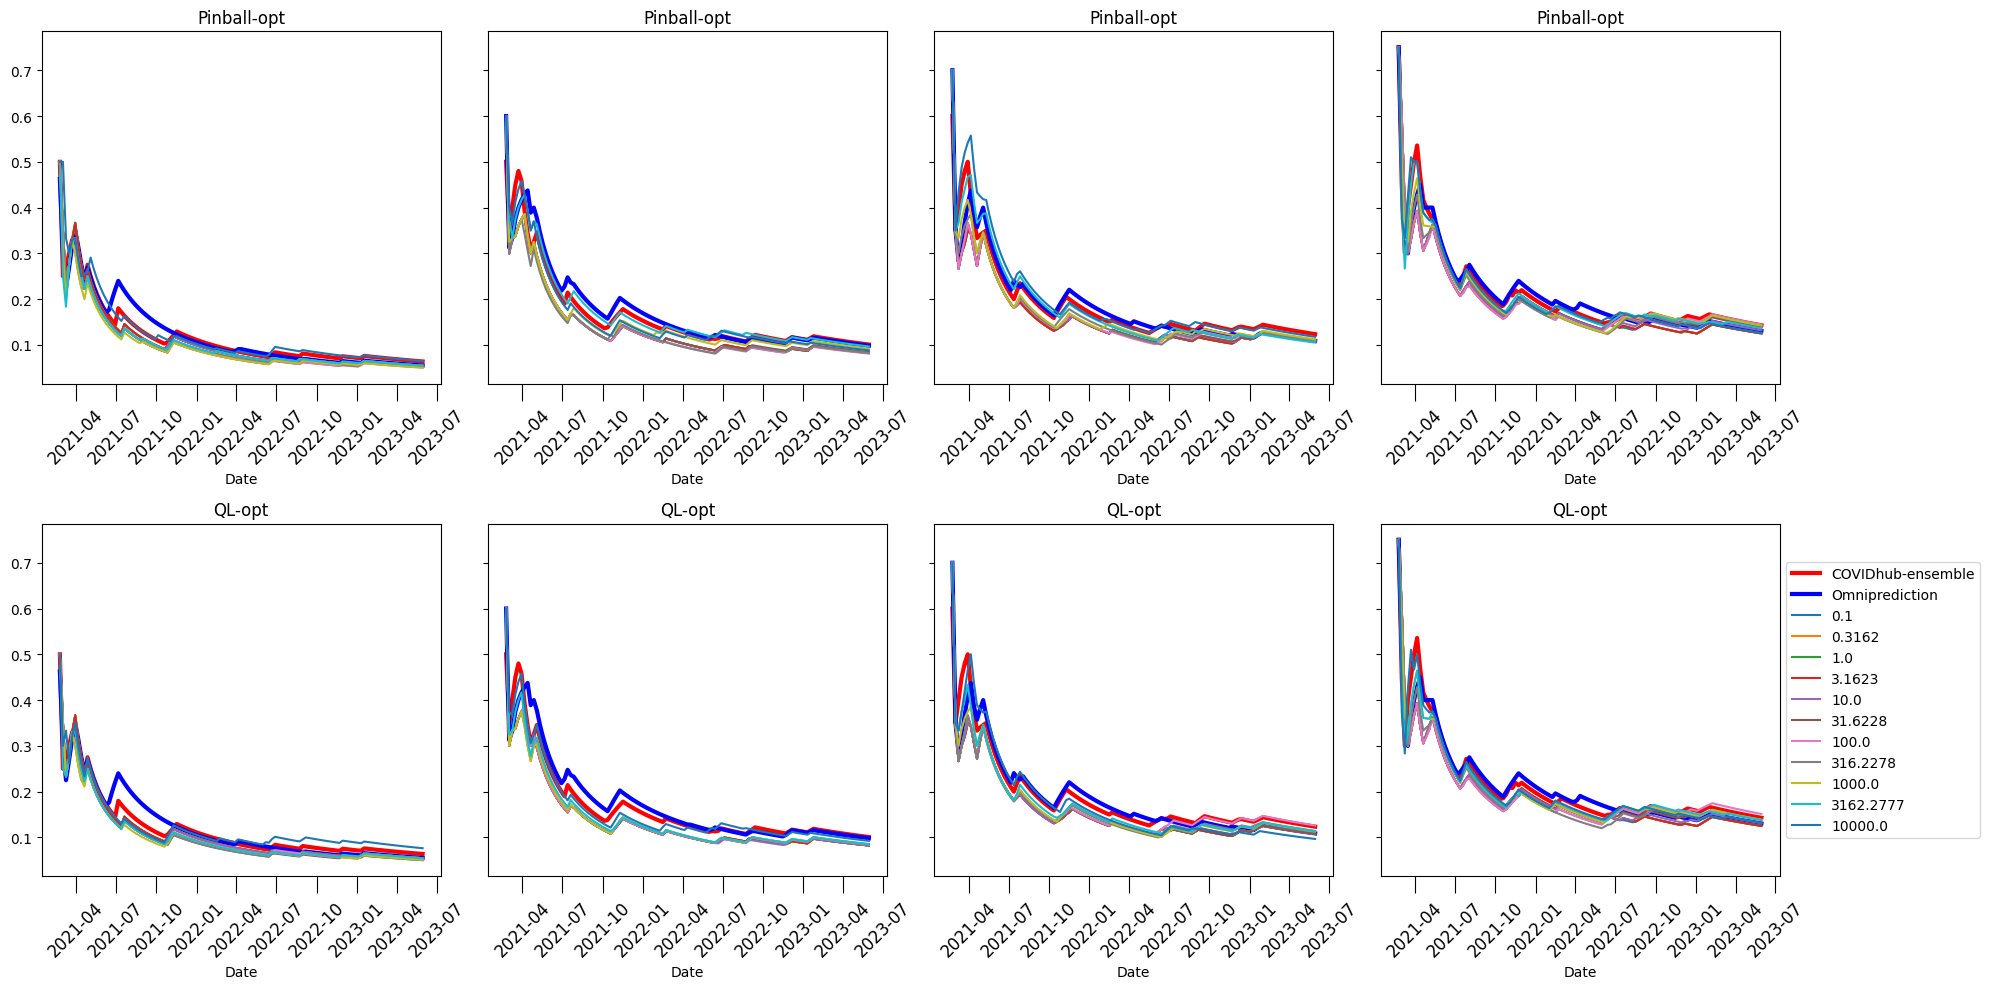

In [54]:
#0442
import matplotlib.pyplot as plt

T = len(d['dates_list'])
dates_list = pd.to_datetime(d['dates_list'])
eta_mult = 2
n_seed = 4

fig, ax = plt.subplots(2, 4, figsize=(20, 10), sharey=True)



from run_omni_v2 import OmniResult

def exp_name_string_v2(w, eta, seed):
    return f"wk{w}_eta{decimal_to_str(eta)}_seed{seed}"

SAVE_DIR_omni = f'../results/hosp0315_weekly_v2'

for w in range(1,5):
    omni_rel_trace = np.zeros((T,))
    for seed in range(1, n_seed+1):
        exp_name = exp_name_string_v2(w, eta_mult, seed)
        results = pickle.load(open(f"{SAVE_DIR_omni}/results_{exp_name}.pkl", 'rb'))
        omni_result = OmniResult(results)
        bfst = omni_result.results['best_forecaster_score_trace']
        # omni_rel_trace += (omni_result.results['omni_score_trace'] - bfst)
        omni_rel_trace += (omni_result.results['omni_score_trace'])
    
    omni_rel_trace /= n_seed
    # ens_omni_rel_trace = (omni_result.ensemble_omni_score_trace - bfst)
    ens_omni_rel_trace = (omni_result.ensemble_omni_score_trace)

    for iax in range(2):
        ax[iax, w-1].plot(dates_list, ens_omni_rel_trace, color='red', linewidth=3, label='COVIDhub-ensemble')
        ax[iax, w-1].plot(dates_list, omni_rel_trace, color='blue', linewidth=3, label='Omniprediction')
        ax[iax, w-1].tick_params(axis='x', labelrotation=45, labelsize=12, size=12)




for w in range(1, 5):
    for eta_mult in eta_list:
        exp_name = exp_name_string_ql_pb(w, eta_mult, round_Y_F=False)
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
        
        ax[0, w-1].plot(dates_list, results['pinball_omni_score_trace'], label=eta_mult)
        ax[1, w-1].plot(dates_list, results['ql_omni_score_trace'], label=eta_mult)

        # assert np.all(results['best_forecaster_score_trace'] == bfst), f"best_forecaster_score_trace: {results['best_forecaster_score_trace']}, bfst: {bfst}"
        ax[0, w-1].set_title(f'Pinball-opt')
        ax[1, w-1].set_title(f'QL-opt')

    ax[0, w-1].set_xlabel('Date')
    ax[1, w-1].set_xlabel('Date')

    # ax[0, w-1].set_ylim(0, 0.2)
    # ax[1, w-1].set_ylim(0, 0.2)

    ax[1, 3].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.tight_layout()
plt.show()


In [25]:


w = 1
for eta_mult in eta_list:
    exp_name = exp_name_string_ql_pb(w, eta_mult, round_Y_F=True)
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
    print(results['pinball_preds_history'])
    print('#'*100)

fig.tight_layout()
plt.show()


[[ 48.66666667  52.41666667  55.91666667 ... 103.91666667 108.66666667
  114.25      ]
 [ 45.66666667  49.08333333  53.08333333 ... 102.08333333 108.25
  114.66666667]
 [ 36.91666667  39.75        43.33333333 ...  89.08333333  94.66666667
  101.66666667]
 ...
 [  8.08333333   9.           9.16666667 ...  32.49999999  35.24999999
   38.91666666]
 [  7.91666667   8.16666667   9.         ...  27.24999999  29.41666666
   32.        ]
 [  8.58333333   9.33333333  10.16666667 ...  26.08333333  27.91666666
   29.91666667]]
####################################################################################################
[[ 48.66666667  52.41666667  55.91666667 ... 103.91666667 108.66666667
  114.25      ]
 [ 45.66666667  49.08333333  53.08333333 ... 102.08333333 108.25
  114.66666667]
 [ 36.91666667  39.75        43.33333333 ...  89.08333333  94.66666667
  101.66666667]
 ...
 [  8.08333333   9.           9.16666667 ...  32.49999997  35.24999998
   38.91666665]
 [  7.91666667   8.16666667   